In [1]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import yellowbrick

print(f'Versión de pandas: {pd.__version__}')
print(f'Versión de numpy: {np.__version__}')
print(f'Versión de scikit-learn (sklearn): {sklearn.__version__}')
print(f'Versión de seaborn: {sns.__version__}')
print(f'Versión de yellowbrick: {yellowbrick.__version__}')

Versión de pandas: 2.2.3
Versión de numpy: 2.2.5
Versión de scikit-learn (sklearn): 1.6.1
Versión de seaborn: 0.13.2
Versión de yellowbrick: 1.5


In [2]:
datos = pd.read_csv ('flights.csv')
datos.shape

(71175, 11)

In [3]:
datos.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271


In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [5]:
datos.describe()

,flight_id,arrival_time,departure_time,day,year,delay
count,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000
mean,15.465135,13.283159,16.480222,182.000000,2016.000000,12.548378
std,8.649646,4.023380,4.143705,105.366769,3.741684,23.125349
min,1.000000,7.065594,10.065594,0.000000,2010.000000,-41.028033
25%,8.000000,8.939996,12.668655,91.000000,2013.000000,-4.412876
50%,15.000000,14.258911,16.376052,182.000000,2016.000000,9.740454
75%,23.000000,16.909690,20.041281,273.000000,2019.000000,27.650853
max,30.000000,19.341235,23.341235,364.000000,2022.000000,125.632352


In [6]:
datos.describe(include='O')

,airline,aircraft_type,schengen,origin
count,71175,71175,71175,71175
unique,3,6,2,10
top,BZ,Airbus A320,schengen,TZF
freq,47598,30778,42569,14162


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt


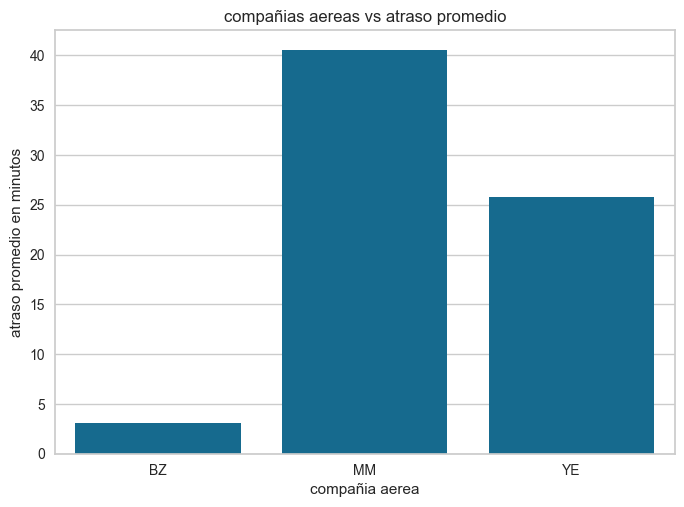

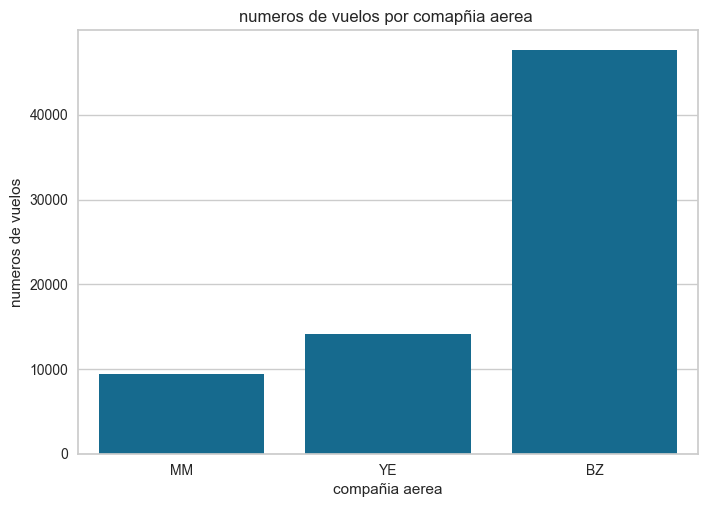

In [8]:
avg_delay = datos.groupby('airline')['delay'].mean().reset_index()
sns.barplot(x='airline', y= 'delay', data=avg_delay)
plt.title('compañias aereas vs atraso promedio')
plt.xlabel('compañia aerea')
plt.ylabel('atraso promedio en minutos')
plt.show()

sns.countplot(data=datos, x='airline')
plt.title('numeros de vuelos por comapñia aerea ')
plt.xlabel('compañia aerea')
plt.ylabel('numeros de vuelos')
plt.show()


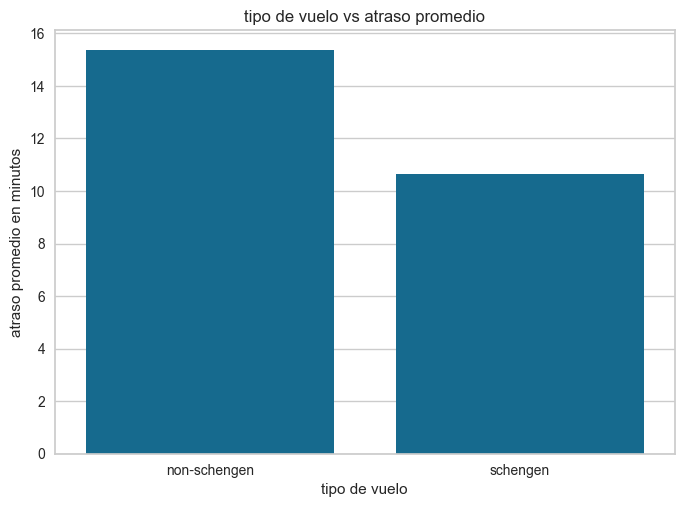

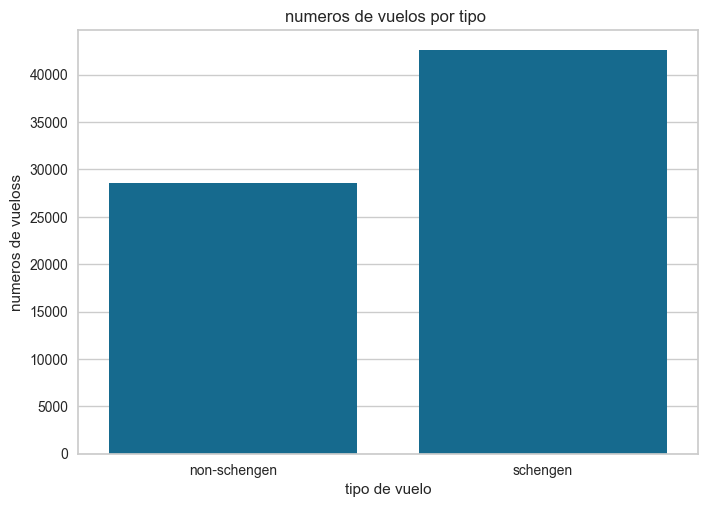

In [9]:
avg_delay = datos.groupby('schengen')['delay'].mean().reset_index()
sns.barplot(x='schengen', y= 'delay', data=avg_delay)
plt.title('tipo de vuelo vs atraso promedio')
plt.xlabel('tipo de vuelo')
plt.ylabel('atraso promedio en minutos')
plt.show()

sns.countplot(data=datos, x='schengen')
plt.title('numeros de vuelos por tipo ')
plt.xlabel('tipo de vuelo')
plt.ylabel('numeros de vueloss')
plt.show()

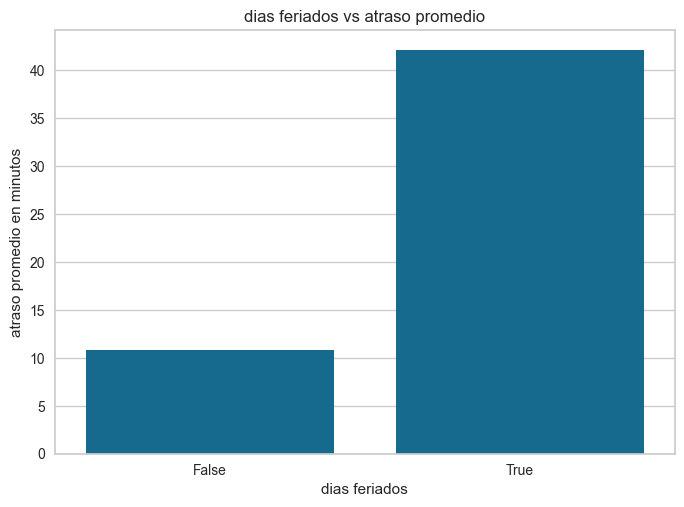

In [10]:
avg_delay = datos.groupby('is_holiday')['delay'].mean().reset_index()
sns.barplot(x='is_holiday', y= 'delay', data=avg_delay)
plt.title('dias feriados vs atraso promedio')
plt.xlabel('dias feriados')
plt.ylabel('atraso promedio en minutos')
plt.show()

In [11]:
order = datos['aircraft_type'].value_counts()#.index
order

#['Airbus A320', 'Airbus A330', 'Boeing 787', 'Embraer E175','Boeing 737', 'Boeing 777']

aircraft_type
Airbus A320     30778
Airbus A330     16654
Boeing 787       9606
Embraer E175     7098
Boeing 737       4722
Boeing 777       2317
Name: count, dtype: int64

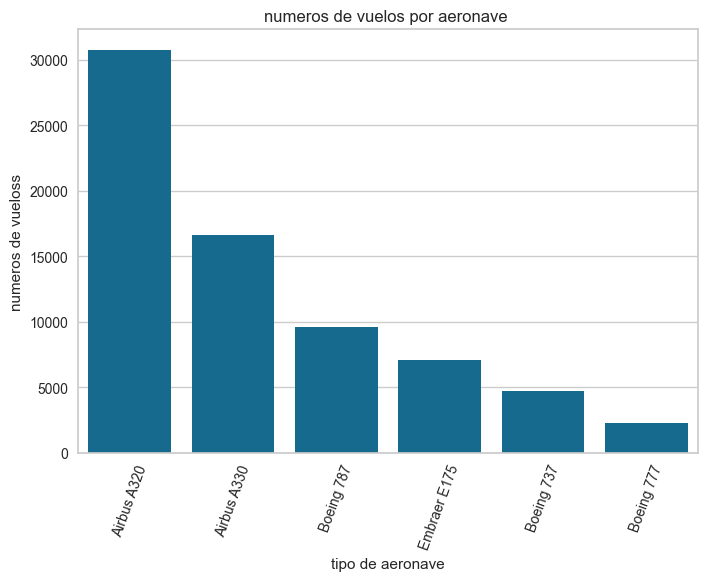

In [12]:
order = datos['aircraft_type'].value_counts().index

sns.countplot(data=datos, x='aircraft_type', order=order)
plt.title('numeros de vuelos por aeronave ')
plt.xticks(rotation=70)
plt.xlabel('tipo de aeronave')
plt.ylabel('numeros de vueloss')
plt.show()

<Axes: xlabel='arrival_time', ylabel='Count'>

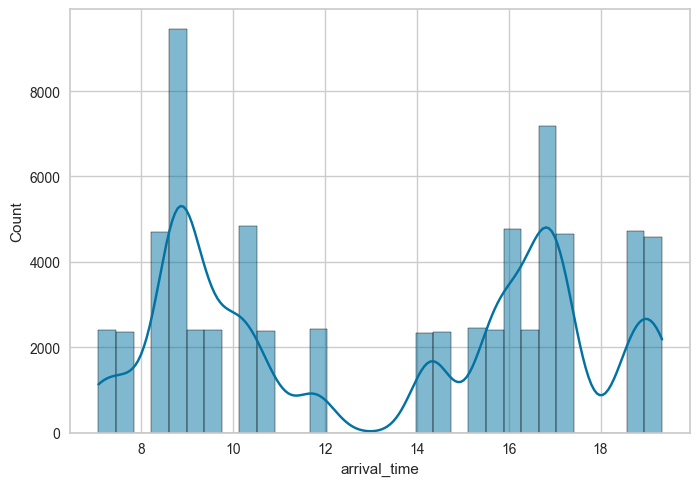

In [15]:
sns.histplot(data = datos, x='arrival_time', kde=True)

In [16]:
import numpy as np


def ancho_bin (df, columna):
    q75, q25 = np.percentile(df[columna], [75, 25])
    iqr = q75 - q25
    ancho = 2 * iqr * np.power(len(df[columna]), -1/3)
    return ancho

<Axes: xlabel='arrival_time', ylabel='Count'>

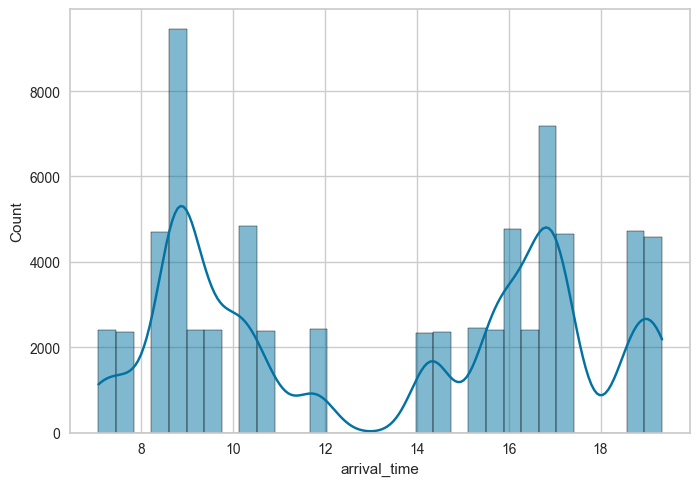

In [19]:
binwidth = ancho_bin(datos, 'arrival_time')
sns.histplot(data = datos, x='arrival_time', kde=True,binwidth=binwidth)



In [ ]:

sns.histplot(data = datos, x='arrival_time', kde=True,bins=10)

<Axes: xlabel='departure_time', ylabel='Count'>

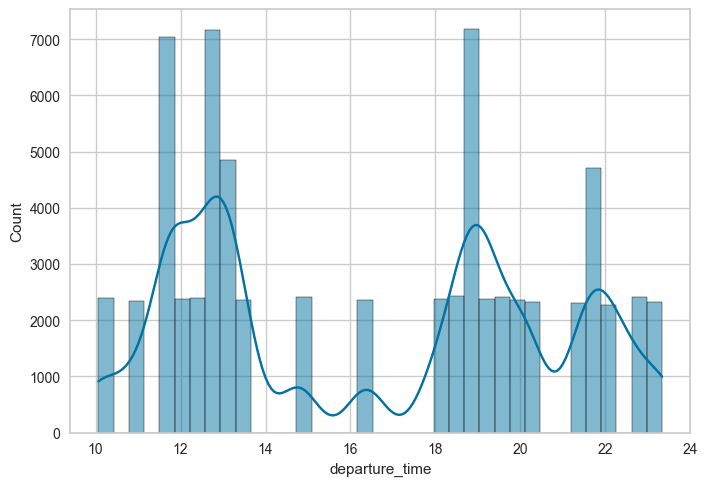

In [20]:
binwidth = ancho_bin(datos, 'departure_time')
sns.histplot(data = datos, x='departure_time', kde=True,binwidth=binwidth)

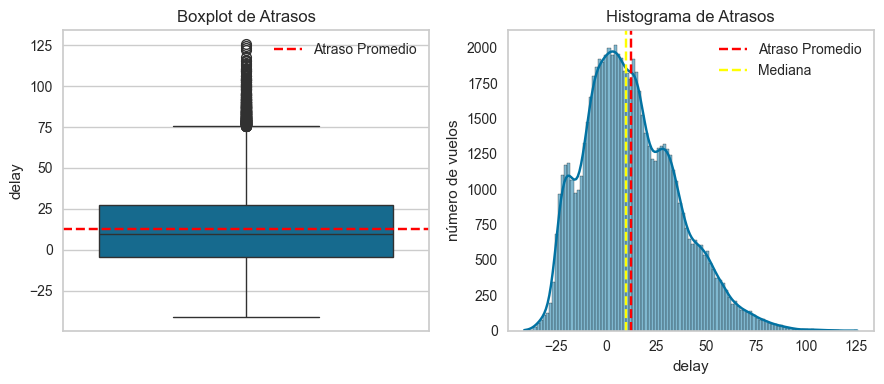

In [34]:
atraso_promedio = datos['delay'].mean()
atraso_mediana = datos['delay'].median()

fig, ax = plt.subplots(1,2, figsize=(9, 4))

sns.boxplot(data=datos, y='delay', ax=ax[0])
ax[0].set_title('Boxplot de Atrasos')
ax[0].axhline(y= atraso_promedio, color='red', linestyle='--', label='Atraso Promedio')
ax[0].legend()

binwidth = ancho_bin(datos, 'delay')
sns.histplot(data=datos, x='delay', kde=True, ax=ax[1],binwidth=binwidth)
plt.ylabel('número de vuelos')
plt.grid(False)
ax[1].set_title('Histograma de Atrasos')
ax[1].axvline(x=atraso_promedio, color='red', linestyle='--', label='Atraso Promedio')
ax[1].axvline(x=atraso_mediana, color='yellow', linestyle='--', label='Mediana')
ax[1].legend()

plt.tight_layout()

plt.show()


In [35]:
datos.columns

Index(['flight_id', 'airline', 'aircraft_type', 'schengen', 'origin',
       'arrival_time', 'departure_time', 'day', 'year', 'is_holiday', 'delay'],
      dtype='object')

In [ ]:
#creacion columna date
datos['date'] = datos['year'].astype(str) + '-' +( datos['day']+1).astype(str)
datos['date'] = pd.to_datetime(datos['date'], format='%Y-%j')
datos.tail()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date
71170,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,364,2022,True,25.677277,2022-12-31
71171,17,BZ,Airbus A330,non-schengen,CNU,16.718722,21.718722,364,2022,True,52.624348,2022-12-31
71172,7,MM,Boeing 787,schengen,TZF,8.564949,13.564949,364,2022,True,56.167080,2022-12-31
71173,5,BZ,Airbus A320,schengen,ZQO,9.344097,12.344097,364,2022,True,56.758844,2022-12-31
71174,29,BZ,Boeing 737,schengen,ZQO,8.591208,11.591208,364,2022,True,41.401648,2022-12-31


In [47]:
#creacion columna fin de semana

datos['is_weekend'] = datos['date'].dt.weekday.isin([5, 6])
datos['day_name'] = datos['date'].dt.day_name()
datos.sample(5)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
35932,13,BZ,Boeing 787,non-schengen,TCY,10.172731,13.172731,205,2016,False,-14.188042,2016-07-24,True,Sunday
2495,30,BZ,Embraer E175,schengen,PUA,8.923441,12.923441,166,2010,False,-14.681429,2010-06-16,False,Wednesday
58432,7,MM,Boeing 787,schengen,TZF,8.564949,13.564949,245,2020,False,35.795224,2020-09-02,False,Wednesday
44440,30,BZ,Embraer E175,schengen,PUA,8.923441,12.923441,42,2018,False,20.063356,2018-02-12,False,Monday
65813,21,BZ,Boeing 737,schengen,FJB,7.065594,10.065594,7,2022,False,30.331851,2022-01-08,True,Saturday


In [48]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   flight_id       71175 non-null  int64         
 1   airline         71175 non-null  object        
 2   aircraft_type   71175 non-null  object        
 3   schengen        71175 non-null  object        
 4   origin          71175 non-null  object        
 5   arrival_time    71175 non-null  float64       
 6   departure_time  71175 non-null  float64       
 7   day             71175 non-null  int64         
 8   year            71175 non-null  int64         
 9   is_holiday      71175 non-null  bool          
 10  delay           71175 non-null  float64       
 11  date            71175 non-null  datetime64[ns]
 12  is_weekend      71175 non-null  bool          
 13  day_name        71175 non-null  object        
dtypes: bool(2), datetime64[ns](1), float64(3), int64(3), o

In [52]:
datos ['schengen'] = datos['schengen'].replace({'non-schengen':0, 'schengen':1})
datos ['is_holiday'] = datos['is_holiday'].replace({False:0, True:1})
datos ['is_weekend'] = datos['is_weekend'].replace({False:0, True:1})
datos.sample(5)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
59,23,YE,Embraer E175,1,TCY,18.801235,21.801235,3,2010,0,2.772991,2010-01-04,0,Monday
31105,17,BZ,Airbus A330,0,CNU,16.718722,21.718722,248,2015,0,-5.437155,2015-09-06,1,Sunday
37238,19,MM,Airbus A320,1,TZF,16.245220,19.245220,292,2016,0,38.276588,2016-10-19,0,Wednesday
21304,19,MM,Airbus A320,1,TZF,16.245220,19.245220,325,2013,0,40.760113,2013-11-22,0,Friday
29543,20,YE,Boeing 787,1,MWL,16.909690,18.909690,144,2015,0,-14.925862,2015-05-25,0,Monday


In [51]:
import warnings 

warnings.filterwarnings('ignore')

In [54]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   flight_id       71175 non-null  int64         
 1   airline         71175 non-null  object        
 2   aircraft_type   71175 non-null  object        
 3   schengen        71175 non-null  int64         
 4   origin          71175 non-null  object        
 5   arrival_time    71175 non-null  float64       
 6   departure_time  71175 non-null  float64       
 7   day             71175 non-null  int64         
 8   year            71175 non-null  int64         
 9   is_holiday      71175 non-null  int64         
 10  delay           71175 non-null  float64       
 11  date            71175 non-null  datetime64[ns]
 12  is_weekend      71175 non-null  int64         
 13  day_name        71175 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(6), object(4)


In [55]:
categoricas = ['airline', 'aircraft_type', 'origin', 'day_name']

pd.get_dummies(datos, columns=categoricas, dtype=int)

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
0,26,0,8.885071,10.885071,0,2010,0,70.205981,2010-01-01,0,...,1,0,0,1,0,0,0,0,0,0
1,10,0,8.939996,11.939996,0,2010,0,38.484609,2010-01-01,0,...,1,0,0,1,0,0,0,0,0,0
2,3,1,18.635384,22.635384,0,2010,0,2.388305,2010-01-01,0,...,0,1,0,1,0,0,0,0,0,0
3,28,0,15.967963,17.967963,0,2010,0,19.138491,2010-01-01,0,...,0,0,0,1,0,0,0,0,0,0
4,15,0,16.571894,19.571894,0,2010,0,15.016271,2010-01-01,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71170,3,1,18.635384,22.635384,364,2022,1,25.677277,2022-12-31,1,...,0,1,0,0,0,1,0,0,0,0
71171,17,0,16.718722,21.718722,364,2022,1,52.624348,2022-12-31,1,...,0,0,0,0,0,1,0,0,0,0
71172,7,1,8.564949,13.564949,364,2022,1,56.167080,2022-12-31,1,...,0,1,0,0,0,1,0,0,0,0
71173,5,1,9.344097,12.344097,364,2022,1,56.758844,2022-12-31,1,...,0,0,1,0,0,1,0,0,0,0


In [56]:
datos_codificados = pd.get_dummies(data = datos, columns=categoricas, dtype=int)
datos_codificados.sample(5)

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
31035,29,1,8.591208,11.591208,244,2015,0,35.607651,2015-09-02,0,...,0,0,1,0,0,0,0,0,0,1
6615,9,0,10.733469,12.733469,76,2011,0,-2.504261,2011-03-18,0,...,0,1,0,1,0,0,0,0,0,0
42466,30,1,8.923441,12.923441,276,2017,0,-1.604100,2017-10-04,0,...,0,0,0,0,0,0,0,0,0,1
41062,16,0,17.041281,20.041281,182,2017,0,84.160402,2017-07-02,1,...,0,0,0,0,0,0,1,0,0,0
48950,27,1,14.376052,16.376052,343,2018,0,25.064125,2018-12-10,0,...,0,0,0,0,1,0,0,0,0,0


In [58]:
datos[['arrival_time', 'departure_time']].corr()


,arrival_time,departure_time
arrival_time,1.000000,0.973797
departure_time,0.973797,1.000000


In [60]:
datos_codificados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   flight_id                   71175 non-null  int64         
 1   schengen                    71175 non-null  int64         
 2   arrival_time                71175 non-null  float64       
 3   departure_time              71175 non-null  float64       
 4   day                         71175 non-null  int64         
 5   year                        71175 non-null  int64         
 6   is_holiday                  71175 non-null  int64         
 7   delay                       71175 non-null  float64       
 8   date                        71175 non-null  datetime64[ns]
 9   is_weekend                  71175 non-null  int64         
 10  airline_BZ                  71175 non-null  int64         
 11  airline_MM                  71175 non-null  int64     

In [62]:
df = datos_codificados.drop(columns=['flight_id', 'departure_time', 'day', 'year', 'date'])
df.sample(10)


,schengen,arrival_time,is_holiday,delay,is_weekend,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
61193,0,15.496519,0,7.821110,1,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
70213,0,15.967963,1,43.717742,0,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
23003,1,9.344097,0,-12.602803,1,1,0,0,1,0,...,0,0,1,0,0,1,0,0,0,0
18747,0,17.041281,0,68.728425,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,1,0
14715,0,15.496519,0,16.382796,1,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
49852,1,14.376052,0,-7.250614,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
38634,0,10.733469,0,1.505665,1,1,0,0,0,1,...,0,1,0,0,0,1,0,0,0,0
52382,0,17.041281,0,40.436445,1,0,1,0,1,0,...,0,0,0,0,0,1,0,0,0,0
63131,0,19.341235,0,10.217540,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
50003,1,19.196804,0,13.386501,0,1,0,0,1,0,...,0,0,1,0,1,0,0,0,0,0


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   schengen                    71175 non-null  int64  
 1   arrival_time                71175 non-null  float64
 2   is_holiday                  71175 non-null  int64  
 3   delay                       71175 non-null  float64
 4   is_weekend                  71175 non-null  int64  
 5   airline_BZ                  71175 non-null  int64  
 6   airline_MM                  71175 non-null  int64  
 7   airline_YE                  71175 non-null  int64  
 8   aircraft_type_Airbus A320   71175 non-null  int64  
 9   aircraft_type_Airbus A330   71175 non-null  int64  
 10  aircraft_type_Boeing 737    71175 non-null  int64  
 11  aircraft_type_Boeing 777    71175 non-null  int64  
 12  aircraft_type_Boeing 787    71175 non-null  int64  
 13  aircraft_type_Embraer E175  711